# Daten importieren

In [1]:
# @title Datenimport
import requests
import zipfile
import io
import os

# URL of the master branch zip file
zip_url = "https://github.com/bstabler/TransportationNetworks/archive/master.zip"

# Directory to extract the contents
extract_dir = "TransportationNetworks_master"

print(f"Downloading data from: {zip_url}")
response = requests.get(zip_url)
response.raise_for_status() # Raise an exception for HTTP errors

print("Extracting data...")
with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
    zf.extractall(extract_dir)
print(f"Data extracted to: {extract_dir}")

Extracting data...
Data extracted to: TransportationNetworks_master


To create the visualization, we first need to parse the `.tntp` files. These files typically have a specific format. I'll read the `Philadelphia_node.tntp` file to get node coordinates and the `Philadelphia_net.tntp` file to get information about the links (edges), including their capacity, which we can use for traffic representation.

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os

# Define the base path to the Philadelphia data
philadelphia_data_path = os.path.join(extract_dir, 'TransportationNetworks-master', 'Philadelphia')

# --- Parse Node File (Philadelphia_node.tntp) ---
node_file_path = os.path.join(philadelphia_data_path, 'Philadelphia_node.tntp')
print(f"Reading node data from: {node_file_path}")

node_data = []
with open(node_file_path, 'r') as f:
    for line in f:
        line = line.strip()
        if line.startswith(';'): # Skip comment lines
            continue
        if line: # Ensure line is not empty
            parts = line.split() # Split by whitespace
            if len(parts) >= 3:
                try:
                    node_id = int(parts[0])
                    x_coord = float(parts[1])
                    y_coord = float(parts[2])
                    node_data.append({'node_id': node_id, 'x': x_coord, 'y': y_coord})
                except ValueError:
                    # print(f"Skipping malformed node line: {line}") # For debugging
                    continue

nodes_df = pd.DataFrame(node_data)

# Let's read the trips file to identify potential zone nodes
trips_file_path = os.path.join(philadelphia_data_path, 'Philadelphia_trips.tntp')
print(f"Reading trip data from: {trips_file_path} to identify zones (origin/destination nodes).")
zone_nodes_set = set()

# Flag to indicate if we are currently parsing an Origin block
in_origin_block = False

with open(trips_file_path, 'r') as f:
    for line in f:
        stripped_line = line.strip()
        if stripped_line.startswith(';'): # Skip comment lines
            continue
        if stripped_line.startswith('Origin'):
            in_origin_block = True
            try:
                # Origin nodes are typically "Origin NNN"
                origin_node = int(stripped_line.split(' ')[1])
                zone_nodes_set.add(origin_node)
            except (ValueError, IndexError):
                # print(f"Warning: Could not parse origin node from line: {stripped_line}")
                pass
        elif in_origin_block:
            # These are typically destination lines within an origin block
            # Format: <destination_node_id> : <demand_value>
            # Or just <destination_node_id> if it's the only thing before ':'
            parts = stripped_line.split(' :')
            if len(parts) > 0 and parts[0].strip().isdigit(): # Ensure it's a number
                try:
                    destination_node = int(parts[0].strip())
                    zone_nodes_set.add(destination_node)
                except (ValueError, IndexError):
                    # If parsing fails, it might be the end of an origin block
                    # or an irrelevant line. Reset in_origin_block.
                    in_origin_block = False
                    # print(f"Warning: Could not parse destination node from line: {stripped_line}")
            else:
                # Line does not contain ':' or doesn't start with a number, so it's likely not a destination entry
                in_origin_block = False # Assume end of block if no more destination entries
        # If not in an origin block and not starting with 'Origin', reset the flag
        elif not stripped_line.startswith('Origin'):
            in_origin_block = False


zone_nodes = list(zone_nodes_set)
print(f"Identified {len(zone_nodes)} zone nodes.")

nodes_df['type'] = nodes_df['node_id'].apply(lambda x: 'zone' if x in zone_nodes else 'crossing')

print("Nodes Data Head:")
display(nodes_df.head())

# --- Parse Network File (Philadelphia_net.tntp) ---
net_file_path = os.path.join(philadelphia_data_path, 'Philadelphia_net.tntp')
print(f"\nReading network data from: {net_file_path}")

network_data = []
header_columns = []
found_header_line = False

with open(net_file_path, 'r') as f:
    for line in f:
        stripped_line = line.strip()
        if stripped_line.startswith(';'):
            continue # Skip comments

        # Look for the data header line. This seems to be the line starting with '~' and containing 'init_node'.
        if stripped_line.startswith('~') and 'init_node' in stripped_line and not found_header_line:
            # Extract column names, cleaning up '~' and splitting by tab. Remove the trailing ';' if present.
            header_str = stripped_line.replace('~', '').strip()

            # Split by tab, then filter out empty strings and the standalone ';'
            raw_header_parts = [col.strip() for col in header_str.split('\t')]
            header_columns_filtered = [p for p in raw_header_parts if p and p != ';']

            # Map standard TNTP column names to user-friendly/consistent names
            column_name_map = {
                'init_node': 'from_node',
                'term_node': 'to_node',
                'capacity': 'Capacity',
                'length': 'Length',
                'free_flow_time': 'free_flow_time',
                'b': 'B',
                'power': 'Power',
                'speed': 'Speed_Limit',
                'toll': 'Toll',
                'link_type': 'Type' # Explicitly map 'link_type' to 'Type'
            }
            header_columns = [column_name_map.get(col.lower(), col) for col in header_columns_filtered]

            found_header_line = True
            continue # Skip to the next line after header

        # After the header, process data lines
        if found_header_line and stripped_line:
            # Data lines are also tab-separated. Remove the trailing ';' if present.
            raw_parts = [p.strip() for p in stripped_line.split('\t')]
            parts = [p for p in raw_parts if p and p != ';'] # Filter out empty strings and the standalone ';'

            if len(parts) == len(header_columns):
                try:
                    row_data = {}
                    for i, col_name in enumerate(header_columns):
                        val = parts[i]
                        # Type conversion based on expected column types
                        if col_name in ['from_node', 'to_node', 'Type']:
                            row_data[col_name] = int(float(val))
                        elif col_name in ['Capacity', 'Length', 'free_flow_time', 'B', 'Power', 'Speed_Limit', 'Toll']:
                            row_data[col_name] = float(val)
                        else:
                            row_data[col_name] = val # Keep as string if not numerical
                    network_data.append(row_data)
                except ValueError:
                    # print(f"Failed to parse data line: {stripped_line}. Parts: {parts}. Header: {header_columns}")
                    continue


# Create DataFrame only if network_data is not empty
if network_data:
    edges_df = pd.DataFrame(network_data)
    # Ensure required columns are present after parsing
    required_edge_cols = ['from_node', 'to_node', 'Capacity', 'free_flow_time']
    if not all(col in edges_df.columns for col in required_edge_cols):
        print("Warning: Some required edge columns are missing after parsing.")
else:
    print("No network data parsed.")
    edges_df = pd.DataFrame(columns=['from_node', 'to_node', 'Capacity', 'free_flow_time'])

print("Edges Data Head:")
display(edges_df.head())

Reading node data from: TransportationNetworks_master\TransportationNetworks-master\Philadelphia\Philadelphia_node.tntp
Reading trip data from: TransportationNetworks_master\TransportationNetworks-master\Philadelphia\Philadelphia_trips.tntp to identify zones (origin/destination nodes).
Identified 1489 zone nodes.
Nodes Data Head:


,node_id,x,y,type
0,1,30208.0,74789.0,zone
1,2,30224.0,74793.0,zone
2,3,30247.0,74783.0,zone
3,4,30220.0,74767.0,zone
4,5,30243.0,74752.0,zone



Reading network data from: TransportationNetworks_master\TransportationNetworks-master\Philadelphia\Philadelphia_net.tntp
Edges Data Head:


,from_node,to_node,Capacity,Length,free_flow_time,B,Power,Speed_Limit,Toll,Type
0,1,4067,999999.0,0.12,0.0,0.15,4.0,0.4,0.0,7
1,1,4073,999999.0,0.12,0.0,0.15,4.0,0.4,0.0,7
2,1,4075,999999.0,0.12,0.0,0.15,4.0,0.4,0.0,7
3,1,8400,999999.0,0.12,0.0,0.15,4.0,0.4,0.0,7
4,2,4059,999999.0,0.12,0.0,0.15,4.0,0.4,0.0,7


# Visualisierung

Now that we have parsed the node and edge data, we can create the visualization. We will use `networkx` to build the graph and `matplotlib` to plot it.

*   **Nodes:** Will be colored differently for 'zones' and 'crossings'.
*   **Edges:** Will have thickness proportional to `Capacity` (representing 'traffic amount'). For direction, we'll use `networkx`'s directed graph plotting which shows arrows.


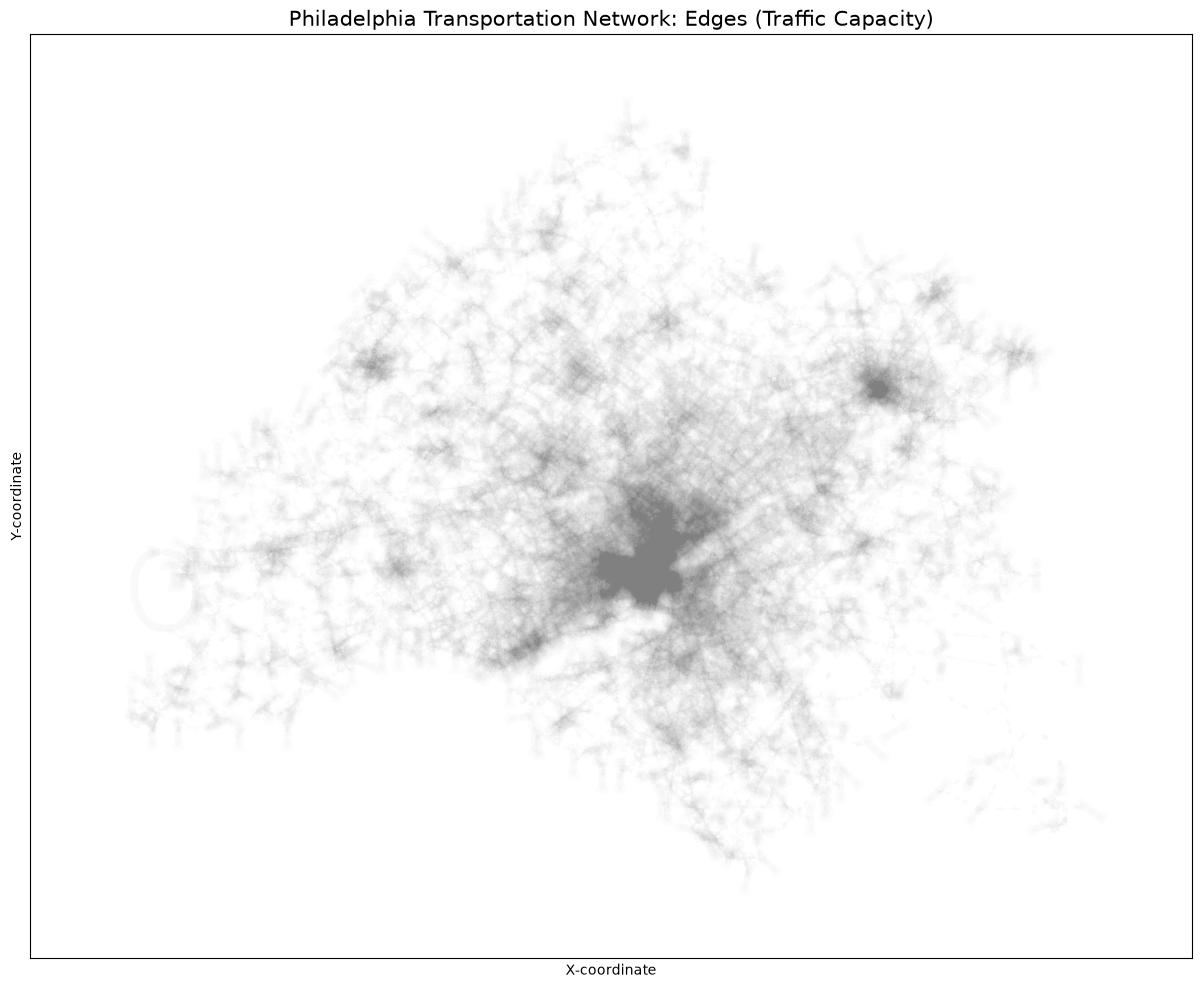

In [4]:
if not nodes_df.empty and not edges_df.empty:
    # Create a directed graph
    G = nx.DiGraph()

    # Add nodes with positions and types (nodes are still added to graph, just not drawn)
    pos = {}
    node_colors = []
    for index, row in nodes_df.iterrows():
        node_id = int(row['node_id'])
        pos[node_id] = (row['x'], row['y'])
        G.add_node(node_id, type=row['type'])
        if row['type'] == 'zone':
            node_colors.append('skyblue')
        else:
            node_colors.append('lightcoral')

    # Add edges with capacities (traffic amount)
    edge_widths = []
    for index, row in edges_df.iterrows():
        from_node = int(row['from_node'])
        to_node = int(row['to_node'])
        capacity = row['Capacity'] # Assuming Capacity represents traffic amount
        G.add_edge(from_node, to_node, capacity=capacity)
        edge_widths.append(capacity / edges_df['Capacity'].max() * 5 + 0.5) # Scale width for better visibility

    # Plot the graph
    plt.figure(figsize=(15, 12))
    # Removed: nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=100)
    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='gray', arrowsize=10, alpha=0.02) # Adjusted alpha

    plt.title('Philadelphia Transportation Network: Edges (Traffic Capacity)', size=15)
    plt.xlabel('X-coordinate')
    plt.ylabel('Y-coordinate')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks([]) # Hide x-axis ticks
    plt.yticks([]) # Hide y-axis ticks

    # Create a legend for node types (optional, as nodes are removed, but kept for context if desired)
    # import matplotlib.patches as mpatches
    # zone_patch = mpatches.Patch(color='skyblue', label='Zone Node')
    # crossing_patch = mpatches.Patch(color='lightcoral', label='Crossing Node')
    # plt.legend(handles=[zone_patch, crossing_patch], loc='lower right')

    plt.show()
else:
    print("Could not visualize: Node or Edge data is empty.")

Let's visualize the distribution of edge capacities using a histogram. This will show us how many edges fall into different capacity ranges.

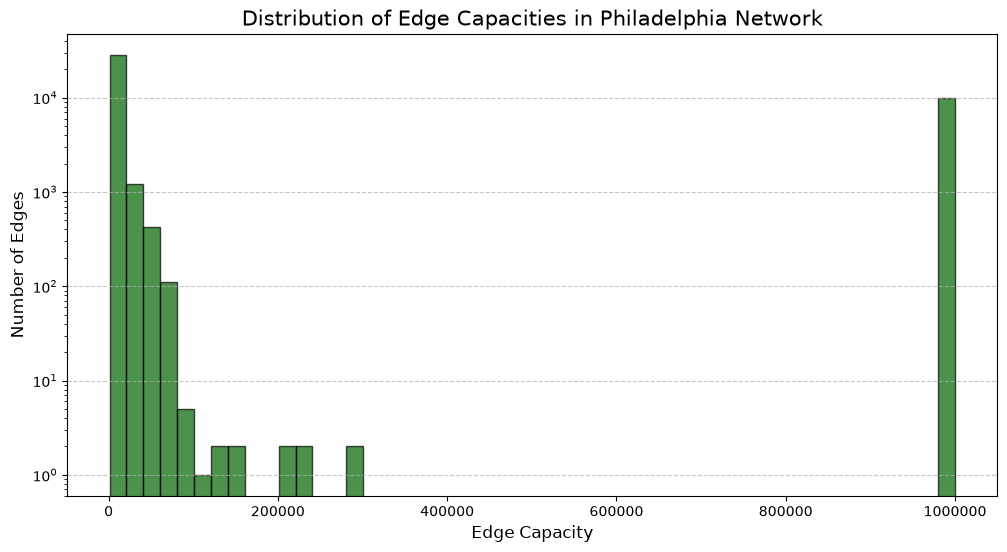

In [5]:
if not edges_df.empty and 'Capacity' in edges_df.columns:
    plt.figure(figsize=(12, 6))

    # Plotting the histogram of edge capacities
    plt.hist(edges_df['Capacity'], bins=50, color='darkgreen', edgecolor='black', alpha=0.7)

    plt.title('Distribution of Edge Capacities in Philadelphia Network', size=15)
    plt.xlabel('Edge Capacity', size=12)
    plt.ylabel('Number of Edges', size=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.yscale('log') # Use a log scale for y-axis to better visualize skewed distributions
    plt.ticklabel_format(style='plain', axis='x') # Prevent scientific notation on x-axis if needed
    plt.show()
else:
    print("Edges DataFrame is empty or 'Capacity' column is missing, cannot plot histogram.")

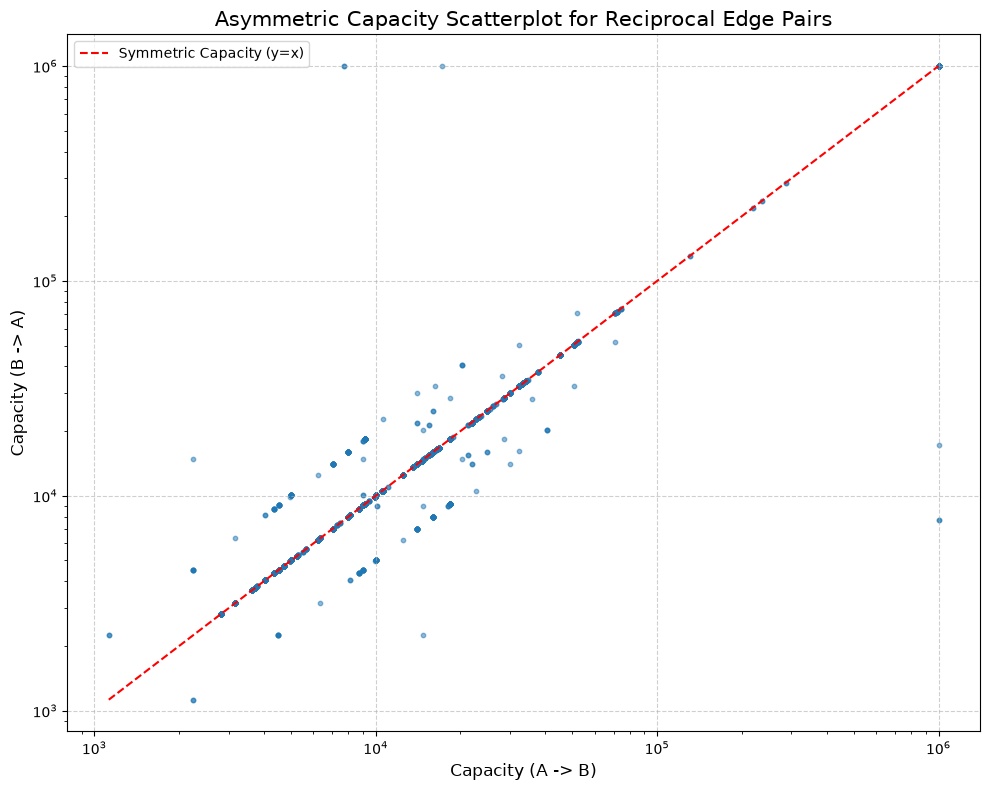

In [6]:
if not edges_df.empty:
    # Prepare data for forward links
    df_forward = edges_df[['from_node', 'to_node', 'Capacity']].copy()
    df_forward = df_forward.rename(columns={'Capacity': 'capacity_ab'})

    # Prepare data for backward/reverse links (swapping from_node and to_node for merging)
    df_backward = edges_df[['to_node', 'from_node', 'Capacity']].copy()
    df_backward = df_backward.rename(columns={'to_node': 'from_node', 'from_node': 'to_node', 'Capacity': 'capacity_ba'})

    # Merge the two DataFrames to find reciprocal links
    # An inner merge ensures we only get pairs where both A->B and B->A exist in the dataset
    reciprocal_edges = pd.merge(df_forward, df_backward, on=['from_node', 'to_node'], how='inner')

    if not reciprocal_edges.empty:
        plt.figure(figsize=(10, 8))
        plt.scatter(reciprocal_edges['capacity_ab'], reciprocal_edges['capacity_ba'], alpha=0.5, s=10) # s=10 for smaller points

        plt.title('Asymmetric Capacity Scatterplot for Reciprocal Edge Pairs', size=15)
        plt.xlabel('Capacity (A -> B)', size=12)
        plt.ylabel('Capacity (B -> A)', size=12)

        # Use log scale as capacities can vary widely
        plt.xscale('log')
        plt.yscale('log')

        plt.grid(True, linestyle='--', alpha=0.6)

        # Add a y=x line to easily identify symmetric capacities
        # Find the max capacity to set limits for the y=x line
        max_cap = max(reciprocal_edges['capacity_ab'].max(), reciprocal_edges['capacity_ba'].max())
        min_cap = min(reciprocal_edges['capacity_ab'].min(), reciprocal_edges['capacity_ba'].min())
        plt.plot([min_cap, max_cap], [min_cap, max_cap], color='red', linestyle='--', label='Symmetric Capacity (y=x)')

        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("No reciprocal edge pairs found to plot an asymmetric scatterplot.")
else:
    print("Edges DataFrame is empty, cannot plot asymmetric scatterplot.")

### In-Degree and Out-Degree Distributions

Let's analyze the connectivity of the nodes by looking at their in-degree (number of incoming edges) and out-degree (number of outgoing edges) distributions.

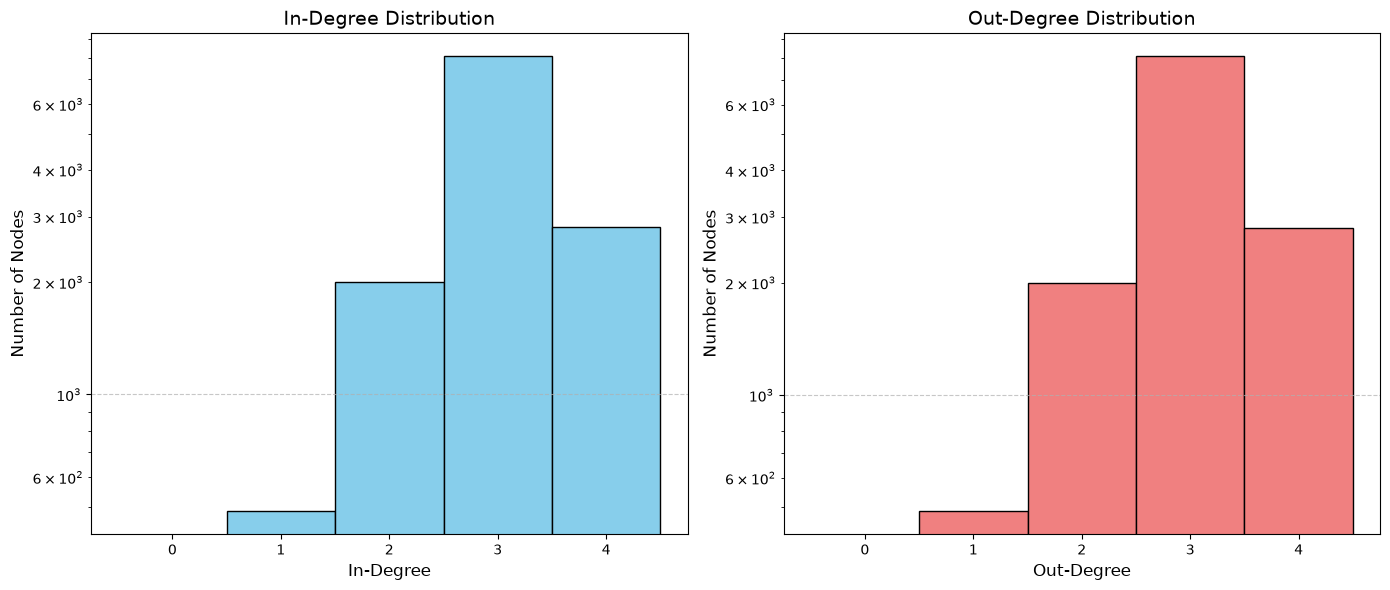

In [7]:
# Calculate in-degrees and out-degrees
in_degrees = [G.in_degree(node) for node in G.nodes()]
out_degrees = [G.out_degree(node) for node in G.nodes()]

plt.figure(figsize=(14, 6))

# Plot In-Degree Distribution
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.hist(in_degrees, bins=range(max(in_degrees) + 2), color='skyblue', edgecolor='black', align='left')
plt.title('In-Degree Distribution', size=14)
plt.xlabel('In-Degree', size=12)
plt.ylabel('Number of Nodes', size=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yscale('log') # Use log scale for y-axis

# Plot Out-Degree Distribution
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.hist(out_degrees, bins=range(max(out_degrees) + 2), color='lightcoral', edgecolor='black', align='left')
plt.title('Out-Degree Distribution', size=14)
plt.xlabel('Out-Degree', size=12)
plt.ylabel('Number of Nodes', size=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yscale('log') # Use log scale for y-axis

plt.tight_layout()
plt.show()

### Capacity vs. Free Flow Time Scatterplot

Let's visualize the relationship between an edge's `Capacity` and its `free_flow_time`.

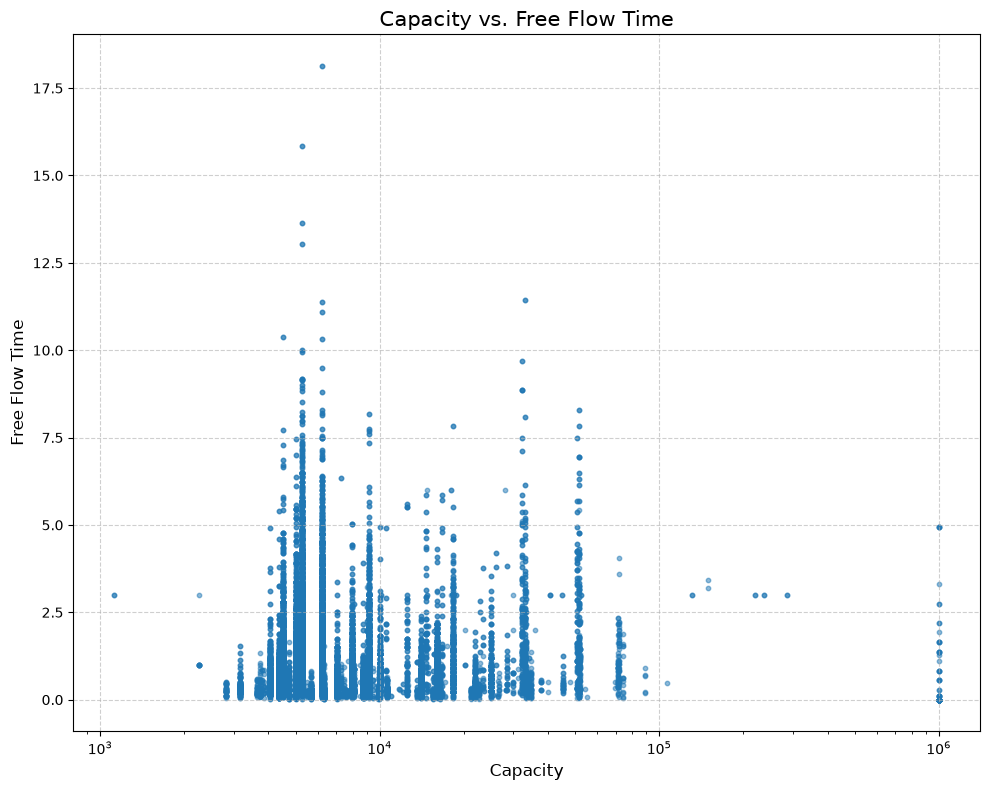

In [8]:
if not edges_df.empty and 'Capacity' in edges_df.columns and 'free_flow_time' in edges_df.columns:
    plt.figure(figsize=(10, 8))
    plt.scatter(edges_df['Capacity'], edges_df['free_flow_time'], alpha=0.5, s=10)

    plt.title('Capacity vs. Free Flow Time', size=15)
    plt.xlabel('Capacity', size=12)
    plt.ylabel('Free Flow Time', size=12)

    # Use log scale for Capacity if its distribution is wide
    if edges_df['Capacity'].max() > 10 * edges_df['Capacity'].min() and edges_df['Capacity'].min() > 0:
        plt.xscale('log')
    # Free flow time can also vary, but let's check its range before applying log
    if edges_df['free_flow_time'].max() > 10 * edges_df['free_flow_time'].min() and edges_df['free_flow_time'].min() > 0:
        plt.yscale('log')

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Edges DataFrame is empty or required columns are missing, cannot plot Capacity vs. Free Flow Time.")

### Distribution of Link Types

Let's examine the distribution of different `Type` (link_type) values within the network edges.

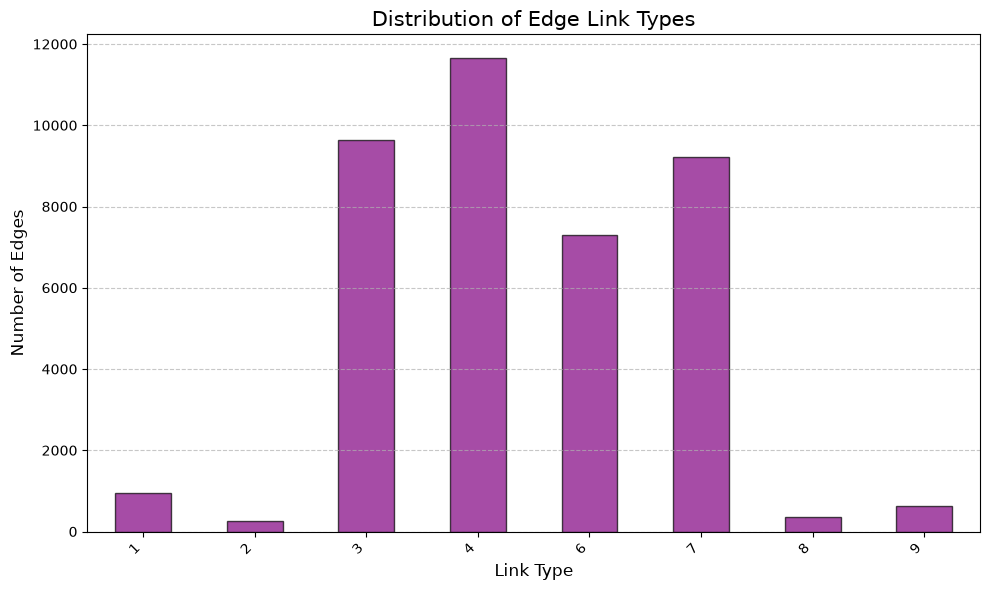

In [9]:
try:
    if not edges_df.empty and 'Type' in edges_df.columns:
        link_type_counts = edges_df['Type'].value_counts().sort_index()

        plt.figure(figsize=(10, 6))
        link_type_counts.plot(kind='bar', color='purple', edgecolor='black', alpha=0.7)
        plt.title('Distribution of Edge Link Types', size=15)
        plt.xlabel('Link Type', size=12)
        plt.ylabel('Number of Edges', size=12)
        plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print("Edges DataFrame is empty or 'Type' column is missing, cannot plot link type distribution.")
except NameError:
    print("Error: 'edges_df' is not defined. Please ensure the data loading and parsing cells (especially 'aa4a92bf') have been executed.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

# Datenmanipulation

In [10]:
import numpy as np
import pandas as pd # Explicitly import pandas for clarity

# Add a binary column 'capacity_is_placeholder'
edges_df['capacity_is_placeholder'] = np.where(edges_df['Capacity'] == 999999.0, 1, 0)

# Apply One-Hot Encoding for 'Type' (Link-Type)
# Drop the original 'Type' column after one-hot encoding
edges_df = pd.get_dummies(edges_df, columns=['Type'], prefix='link_type')

print("Added 'capacity_is_placeholder' column and applied One-Hot Encoding to 'Type'.")
display(edges_df.head())

Added 'capacity_is_placeholder' column and applied One-Hot Encoding to 'Type'.


,from_node,to_node,Capacity,Length,free_flow_time,B,Power,Speed_Limit,Toll,capacity_is_placeholder,link_type_1,link_type_2,link_type_3,link_type_4,link_type_6,link_type_7,link_type_8,link_type_9
0,1,4067,999999.0,0.12,0.0,0.15,4.0,0.4,0.0,1,False,False,False,False,False,True,False,False
1,1,4073,999999.0,0.12,0.0,0.15,4.0,0.4,0.0,1,False,False,False,False,False,True,False,False
2,1,4075,999999.0,0.12,0.0,0.15,4.0,0.4,0.0,1,False,False,False,False,False,True,False,False
3,1,8400,999999.0,0.12,0.0,0.15,4.0,0.4,0.0,1,False,False,False,False,False,True,False,False
4,2,4059,999999.0,0.12,0.0,0.15,4.0,0.4,0.0,1,False,False,False,False,False,True,False,False


In [11]:
columns_to_drop = ['B', 'Power', 'Speed_Limit']
edges_df = edges_df.drop(columns=columns_to_drop, errors='ignore')

print(f"Dropped columns: {columns_to_drop}")
print("Updated edges_df head:")
display(edges_df.head())

Dropped columns: ['B', 'Power', 'Speed_Limit']
Updated edges_df head:


,from_node,to_node,Capacity,Length,free_flow_time,Toll,capacity_is_placeholder,link_type_1,link_type_2,link_type_3,link_type_4,link_type_6,link_type_7,link_type_8,link_type_9
0,1,4067,999999.0,0.12,0.0,0.0,1,False,False,False,False,False,True,False,False
1,1,4073,999999.0,0.12,0.0,0.0,1,False,False,False,False,False,True,False,False
2,1,4075,999999.0,0.12,0.0,0.0,1,False,False,False,False,False,True,False,False
3,1,8400,999999.0,0.12,0.0,0.0,1,False,False,False,False,False,True,False,False
4,2,4059,999999.0,0.12,0.0,0.0,1,False,False,False,False,False,True,False,False


### Feature Engineering: Capacity Ratios and Node Coordinate Differences

Based on the low correlations, let's engineer some potentially more informative features:

1.  **Reciprocal Capacity Ratios**: For a directed edge A->B, if a reciprocal edge B->A exists, we can calculate the ratio of their capacities (Capacity(A->B) / Capacity(B->A)). This might capture imbalances in traffic flow or structural properties.
2.  **Node Coordinate Differences**: The spatial relationship between connected nodes could be crucial. We will add features representing the absolute difference in `x` and `y` coordinates between the `from_node` and `to_node` for each edge.

In [12]:
import numpy as np
import pandas as pd

# --- Consolidated logic from previous cells ---
# (Originally from 58269321 and aadfb5d8)

# Add a binary column 'capacity_is_placeholder'
edges_df['capacity_is_placeholder'] = np.where(edges_df['Capacity'] == 999999.0, 1, 0)
print("Added 'capacity_is_placeholder' column.")

# Apply One-Hot Encoding for 'Type' (Link-Type)
# Drop the original 'Type' column after one-hot encoding
if 'Type' in edges_df.columns:
    edges_df = pd.get_dummies(edges_df, columns=['Type'], prefix='link_type')
    print("Applied One-Hot Encoding to 'Type'.")
else:
    print("'Type' column not found, One-Hot Encoding skipped.")

# Drop unnecessary columns
columns_to_drop = ['B', 'Power', 'Speed_Limit']
edges_df = edges_df.drop(columns=columns_to_drop, errors='ignore')
print(f"Dropped columns: {columns_to_drop}")

# --- Original logic from cell b3a333c2 ---

# --- 1. Reciprocal Capacity Ratios ---
# Create a temporary DataFrame for easier merging to find reciprocal links
reciprocal_df = edges_df[['from_node', 'to_node', 'Capacity']].copy()
reciprocal_df = reciprocal_df.rename(columns={
    'from_node': 'recip_to_node', # The 'from' of the reciprocal is 'to' of original
    'to_node': 'recip_from_node', # The 'to' of the reciprocal is 'from' of original
    'Capacity': 'recip_Capacity'
})

# Merge edges_df with the reciprocal_df to find corresponding reciprocal links
# We join original (from, to) with reciprocal (recip_from, recip_to)
edges_with_recip_cap = pd.merge(
    edges_df,
    reciprocal_df,
    left_on=['from_node', 'to_node'],
    right_on=['recip_from_node', 'recip_to_node'],
    how='left' # Keep all original edges, add reciprocal info if exists
)

# Calculate capacity ratio if reciprocal exists, otherwise fill with 0 (or another meaningful default)
edges_with_recip_cap['capacity_ratio'] = edges_with_recip_cap['Capacity'] / edges_with_recip_cap['recip_Capacity']
edges_with_recip_cap['has_reciprocal'] = edges_with_recip_cap['recip_Capacity'].notna().astype(int)

# Fill NaN for capacity_ratio where no reciprocal exists (e.g., with 0 or 1 if no reciprocal means symmetric)
# Using 0 for now as it means 'no reciprocal contribution to ratio'
edges_with_recip_cap['capacity_ratio'] = edges_with_recip_cap['capacity_ratio'].fillna(0)

# Drop temporary columns from the merge
edges_df = edges_with_recip_cap.drop(columns=['recip_from_node', 'recip_to_node', 'recip_Capacity'])


# --- 2. Node Coordinate Differences ---
# Merge nodes_df to get 'from_node' coordinates
edges_df = pd.merge(edges_df, nodes_df[['node_id', 'x', 'y']],
                    left_on='from_node', right_on='node_id', how='left',
                    suffixes=('', '_from'))
edges_df = edges_df.rename(columns={'x': 'x_from', 'y': 'y_from'})

# Merge nodes_df again to get 'to_node' coordinates
edges_df = pd.merge(edges_df, nodes_df[['node_id', 'x', 'y']],
                    left_on='to_node', right_on='node_id', how='left',
                    suffixes=('', '_to'))
edges_df = edges_df.rename(columns={'x': 'x_to', 'y': 'y_to'})

# Calculate coordinate differences (absolute values)
edges_df['delta_x'] = (edges_df['x_to'] - edges_df['x_from']).abs()
edges_df['delta_y'] = (edges_df['y_to'] - edges_df['y_from']).abs()

# Drop temporary node_id columns and original coordinate columns
edges_df = edges_df.drop(columns=['node_id', 'node_id_from', 'node_id_to', 'x_from', 'y_from', 'x_to', 'y_to'], errors='ignore')

print("Added 'capacity_ratio', 'has_reciprocal', 'delta_x', and 'delta_y' features to edges_df.")
display(edges_df.head())

Added 'capacity_is_placeholder' column.
'Type' column not found, One-Hot Encoding skipped.
Dropped columns: ['B', 'Power', 'Speed_Limit']
Added 'capacity_ratio', 'has_reciprocal', 'delta_x', and 'delta_y' features to edges_df.


,from_node,to_node,Capacity,Length,free_flow_time,Toll,capacity_is_placeholder,link_type_1,link_type_2,link_type_3,link_type_4,link_type_6,link_type_7,link_type_8,link_type_9,capacity_ratio,has_reciprocal,delta_x,delta_y
0,1,4067,999999.0,0.12,0.0,0.0,1,False,False,False,False,False,True,False,False,1.0,1,3.0,2.0
1,1,4073,999999.0,0.12,0.0,0.0,1,False,False,False,False,False,True,False,False,1.0,1,1.0,10.0
2,1,4075,999999.0,0.12,0.0,0.0,1,False,False,False,False,False,True,False,False,1.0,1,3.0,4.0
3,1,8400,999999.0,0.12,0.0,0.0,1,False,False,False,False,False,True,False,False,1.0,1,4.0,3.0
4,2,4059,999999.0,0.12,0.0,0.0,1,False,False,False,False,False,True,False,False,1.0,1,1.0,3.0


In [25]:
# Install torch_geometric and its dependencies
import torch

def install_torch_geometric():
    if torch.cuda.is_available():
        print("CUDA is available, installing torch-scatter and torch-sparse with CUDA support...")
        # Get CUDA version (e.g., 'cu118' for CUDA 11.8)
        cuda_version = torch.version.cuda.replace('.', '')
        torch_version = torch.__version__.split('+')[0]

        !pip install torch-scatter -f https://data.pyg.org/whl/torch-{torch_version}+{cuda_version}.html
        !pip install torch-sparse -f https://data.pyg.org/whl/torch-{torch_version}+{cuda_version}.html
    else:
        print("CUDA not available, installing CPU-only versions of torch-scatter and torch-sparse...")
        !pip install torch-scatter torch-sparse

    print("Installing torch-geometric...")
    !pip install torch_geometric

# Call the installation function
install_torch_geometric()

print("Installation of torch_geometric and its dependencies complete. Please re-run the subsequent cells.")

CUDA not available, installing CPU-only versions of torch-scatter and torch-sparse...
  Using cached torch_scatter-2.1.2.tar.gz (108 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Installing torch-geometric...


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [23 lines of output]
      Traceback (most recent call last):
        File "C:\Users\gurke\PycharmProjects\Guericke_GNN\.venv\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "C:\Users\gurke\PycharmProjects\Guericke_GNN\.venv\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\gurke\PycharmProjects\Guericke_GNN\.venv\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
          return hook(config_settings)
        File "C:\Users\gurke\AppData\Local\Temp\pip-build-env-v2j7gwo8\overlay\Lib\site-packages\setuptools\

Installation of torch_geometric and its dependencies complete. Please re-run the subsequent cells.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import torch
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler

# Step 1: Map original node IDs to contiguous integers for torch_geometric
# Get all unique nodes from 'from_node' and 'to_node'
all_nodes = pd.concat([edges_df['from_node'], edges_df['to_node']]).unique()
all_nodes.sort() # Ensure consistent mapping

# Create a mapping from original node ID to new contiguous ID (0 to N-1)
node_id_mapping = {original_id: new_id for new_id, original_id in enumerate(all_nodes)}

# Apply mapping to edges_df (for consistency, though not directly used in edge_index creation now)
edges_df['from_node_mapped'] = edges_df['from_node'].map(node_id_mapping)
edges_df['to_node_mapped'] = edges_df['to_node'].map(node_id_mapping)

num_nodes = len(all_nodes)
print(f"Original number of nodes: {len(all_nodes)}")
print(f"Number of nodes for torch_geometric: {num_nodes}")

# Create edge_index tensor
# Convert to a 2xN tensor, where N is the number of edges
edge_index = torch.tensor(edges_df[['from_node_mapped', 'to_node_mapped']].values.T, dtype=torch.long)

# Identify columns for edge_attr
# Numerical features that are definitely present and desired
numerical_cols = ['Capacity', 'Length', 'free_flow_time', 'Toll', 'capacity_ratio', 'delta_x', 'delta_y'] # Added new numerical features
binary_cols = ['capacity_is_placeholder', 'has_reciprocal'] # Added new binary feature
ohe_cols = [col for col in edges_df.columns if col.startswith('link_type_')]

# Combine all desired attribute columns
edge_attr_columns = numerical_cols + binary_cols + ohe_cols

# Convert selected columns to appropriate types before creating tensor
# This ensures consistency and avoids potential 'object' type issues
for col in numerical_cols + binary_cols + ohe_cols:
    if col in edges_df.columns:
        edges_df[col] = edges_df[col].astype(float) # Convert all to float for consistency

# Create edge_attr tensor from these columns
edge_attr = torch.tensor(edges_df[edge_attr_columns].values, dtype=torch.float)

# --- Prepare Node Features (data.x) ---
# The 'x' and 'y' coordinates are our node features.
# We need to ensure nodes_df is sorted by mapped node_id to align with torch_geometric's node indexing (0 to num_nodes-1).
# First, map original node_id to new contiguous IDs in nodes_df
nodes_df['node_id_mapped'] = nodes_df['node_id'].map(node_id_mapping)
# Sort by mapped ID to ensure features are in correct order
nodes_df_sorted = nodes_df.sort_values('node_id_mapped').reset_index(drop=True)

# Extract coordinates for scaling
node_coords = nodes_df_sorted[['x', 'y']].values

# Normalize node coordinates using StandardScaler
# Fit and transform on the entire node dataset, as data.x is not split by RandomLinkSplit
scaler_node_coords = StandardScaler()
scaled_node_coords = scaler_node_coords.fit_transform(node_coords)

# Create node features tensor
x = torch.tensor(scaled_node_coords, dtype=torch.float)

print("Edge Index Head:")
print(edge_index[:, :5])
print("\nEdge Attributes (first 5 rows, first few columns):")
print(edge_attr[:5, :])
print(f"\nShape of edge_attr: {edge_attr.shape}")
print(f"Columns used for edge_attr: {edge_attr_columns}")
print("\nNode Features (first 5 rows, scaled coordinates):")
print(x[:5, :])
print(f"Shape of node features (x): {x.shape}")

Original number of nodes: 13389
Number of nodes for torch_geometric: 13389
Edge Index Head:
tensor([[   0,    0,    0,    0,    1],
        [4066, 4072, 4074, 8399, 4058]])

Edge Attributes (first 5 rows, first few columns):
tensor([[1.0000e+06, 1.2000e-01, 0.0000e+00, 0.0000e+00, 1.0000e+00, 3.0000e+00,
         2.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.0000e+06, 1.2000e-01, 0.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00,
         1.0000e+01, 1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.0000e+06, 1.2000e-01, 0.0000e+00, 0.0000e+00, 1.0000e+00, 3.0000e+00,
         4.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.0000e+06, 1.2000e-01, 0.0000e+00, 0.0000e+00, 1.0000e+00, 4.0000e+00

In [17]:
# Step 2: Create a PyTorch Geometric Data object
# For this task, we will provide x (node features), num_nodes, edge_index, and edge_attr
data = Data(x=x, edge_index=edge_index, num_nodes=num_nodes, edge_attr=edge_attr)

print(f"PyTorch Geometric Data object created:\n{data}")
print(f"Shape of node features (x): {data.x.shape}")
print(f"Shape of edge_attr: {data.edge_attr.shape}")

PyTorch Geometric Data object created:
Data(x=[13389, 2], edge_index=[2, 40003], edge_attr=[40003, 17], num_nodes=13389)
Shape of node features (x): torch.Size([13389, 2])
Shape of edge_attr: torch.Size([40003, 17])


In [18]:
import torch
from torch_geometric.transforms import RandomLinkSplit

# Step 3: Apply RandomLinkSplit
# We want 80% for training, 10% for validation, 10% for test
# test_ratio + val_ratio = 0.2
# Neg_sampling_ratio: 2.0 means 2 negative samples for each positive in train, val, and test
transform = RandomLinkSplit(
    is_undirected=False, # The graph is directed
    add_negative_train_samples=True, # Set to True to include negative samples in training
    neg_sampling_ratio=2.0 # 2 negative samples for each positive in train, val, and test
)

# Apply the transform to get the split data
train_data, val_data, test_data = transform(data)

# Explicitly assign node features (x) to split data objects
# RandomLinkSplit usually propagates `x` but this ensures it's always set.
# This is crucial for models like GATv2 that rely on `data.x`.
train_data.x = data.x
val_data.x = data.x
test_data.x = data.x

print("Data split into training, validation, and test sets.")

# Print shapes of node features (x) for verification
print(f"train_data.x shape: {train_data.x.shape}")
print(f"val_data.x shape: {val_data.x.shape}")
print(f"test_data.x shape: {test_data.x.shape}")

# For val_data and test_data, edge_label_index contains both positive and negative samples
# Use edge_label to separate them
train_pos_edges = (train_data.edge_label == 1).sum().item()
train_neg_edges = (train_data.edge_label == 0).sum().item()
val_pos_edges = (val_data.edge_label == 1).sum().item()
val_neg_edges = (val_data.edge_label == 0).sum().item()
test_pos_edges = (test_data.edge_label == 1).sum().item()
test_neg_edges = (test_data.edge_label == 0).sum().item()

print(f"Training edges (positive): {train_pos_edges}")
print(f"Training edges (negative): {train_neg_edges}")
print(f"Validation edges (positive): {val_pos_edges}")
print(f"Validation edges (negative): {val_neg_edges}")
print(f"Test edges (positive): {test_pos_edges}")
print(f"Test edges (negative): {test_neg_edges}")

print("\nExample of validation positive edges (first 5):")
# Select positive samples from edge_label_index using edge_label
print(val_data.edge_label_index[:, val_data.edge_label == 1][:, :5])
print("\nExample of validation negative edges (first 5):")
# Select negative samples from edge_label_index using edge_label
print(val_data.edge_label_index[:, val_data.edge_label == 0][:, :5])

# --- Manual construction of edge_label_attr for all splits ---
# And correct construction of train_data.edge_attr for GNN message passing.

# Create a lookup map for original edge attributes by (src, dst) tuple
original_edge_map = {}
for i in range(data.edge_index.size(1)): # data.edge_index refers to the full graph
    src = data.edge_index[0, i].item()
    dst = data.edge_index[1, i].item()
    original_edge_map[(src, dst)] = i

num_original_features = data.edge_attr.size(1)

# --- Construct train_data.edge_attr (for GNN message passing) ---
# This should contain features ONLY for the positive edges in train_data.edge_index
# train_data.edge_index contains the edges used to build the training graph (positive edges)
train_gnn_edge_attr = torch.zeros(train_data.edge_index.size(1), num_original_features, dtype=data.edge_attr.dtype)
for i in range(train_data.edge_index.size(1)):
    src, dst = train_data.edge_index[0, i].item(), train_data.edge_index[1, i].item()
    original_idx = original_edge_map.get((src, dst))
    if original_idx is not None:
        train_gnn_edge_attr[i] = data.edge_attr[original_idx]
    else:
        # This should not happen for positive edges from original graph, but a safeguard
        print(f"Warning: Positive train edge ({src}, {dst}) not found in original_edge_map for train_data.edge_attr construction.")

train_data.edge_attr = train_gnn_edge_attr
print(f"Constructed train_data.edge_attr shape (for GNN message passing): {train_data.edge_attr.shape}")

# --- Construct edge_label_attr for all splits (for link prediction head) ---
for split_data in [train_data, val_data, test_data]:
    num_total_edges_for_label = split_data.edge_label_index.size(1)
    split_edge_label_attr = torch.zeros(num_total_edges_for_label, num_original_features, dtype=data.edge_attr.dtype)

    # Get features for positive samples from original data.edge_attr
    pos_mask = (split_data.edge_label == 1)
    pos_edge_index = split_data.edge_label_index[:, pos_mask]

    if pos_edge_index.size(1) > 0:
        pos_attrs_list = []
        for i in range(pos_edge_index.size(1)):
            src, dst = pos_edge_index[0, i].item(), pos_edge_index[1, i].item()
            original_idx = original_edge_map.get((src, dst))
            if original_idx is not None:
                pos_attrs_list.append(data.edge_attr[original_idx])
            else:
                # This case should ideally not happen for positive samples if data.edge_index is complete
                pos_attrs_list.append(torch.zeros(num_original_features, dtype=data.edge_attr.dtype))
        if pos_attrs_list:
            split_edge_label_attr[pos_mask] = torch.stack(pos_attrs_list)

    # Generate features for negative samples
    neg_mask = (split_data.edge_label == 0)
    num_neg_samples = neg_mask.sum().item()

    if num_neg_samples > 0 and data.edge_attr.size(0) > 0:
        # Sample attributes for negative edges randomly from the original graph's edge_attr
        random_indices = torch.randint(0, data.edge_attr.size(0), (num_neg_samples,))
        split_edge_label_attr[neg_mask] = data.edge_attr[random_indices]

    # Assign to edge_label_attr for all splits
    split_data.edge_label_attr = split_edge_label_attr # Predictor uses this for link features

    split_data_name = 'train_data' if split_data == train_data else ('val_data' if split_data == val_data else 'test_data')
    print(f"Manually constructed {split_data_name}.edge_label_attr shape: {split_data.edge_label_attr.shape}")

    # Remove the potentially misleading edge_attr from val/test data if it exists and is not the intended one
    if split_data != train_data and hasattr(split_data, 'edge_attr') and split_data.edge_attr is not None:
        # Only delete if it's not edge_label_attr (which we just assigned) or if it's not the newly created train_data.edge_attr
        if split_data.edge_attr.data_ptr() != split_data.edge_label_attr.data_ptr():
            del split_data.edge_attr
            print(f"Removed redundant {split_data_name}.edge_attr.")


print("\n--- Feature Tensor Debugging (after manual construction) ---")

# train_data
train_attr_str = 'Not present'
if hasattr(train_data, 'edge_attr') and train_data.edge_attr is not None:
    train_attr_str = str(train_data.edge_attr.shape)
print(f"train_data.edge_attr shape: {train_attr_str}")

# train_data.edge_label_attr
train_edge_label_attr_str = 'Not present or None'
if hasattr(train_data, 'edge_label_attr') and train_data.edge_label_attr is not None:
    train_edge_label_attr_str = str(train_data.edge_label_attr.shape)
print(f"train_data.edge_label_attr shape: {train_edge_label_attr_str}")

# val_data.edge_attr
val_edge_attr_str = 'Not present or None'
if hasattr(val_data, 'edge_attr') and val_data.edge_attr is not None:
    val_edge_attr_str = str(val_data.edge_attr.shape)
print(f"val_data.edge_attr shape: {val_edge_attr_str}")

# val_data.edge_label_attr
val_edge_label_attr_str = 'Not present or None'
if hasattr(val_data, 'edge_label_attr') and val_data.edge_label_attr is not None:
    val_edge_label_attr_str = str(val_data.edge_label_attr.shape)
print(f"val_data.edge_label_attr shape: {val_edge_label_attr_str}")

# test_data.edge_attr
test_attr_str = 'Not present or None' # Initialize variable to prevent NameError
if hasattr(test_data, 'edge_attr') and test_data.edge_attr is not None:
    test_attr_str = str(test_data.edge_attr.shape)
print(f"test_data.edge_attr shape: {test_attr_str}")

# test_data.edge_label_attr
test_edge_label_attr_str = 'Not present or None'
if hasattr(test_data, 'edge_label_attr') and test_data.edge_label_attr is not None:
    test_edge_label_attr_str = str(test_data.edge_label_attr.shape)
print(f"test_data.edge_label_attr shape: {test_edge_label_attr_str}")

Data split into training, validation, and test sets.
train_data.x shape: torch.Size([13389, 2])
val_data.x shape: torch.Size([13389, 2])
test_data.x shape: torch.Size([13389, 2])
Training edges (positive): 28003
Training edges (negative): 56006
Validation edges (positive): 4000
Validation edges (negative): 8000
Test edges (positive): 8000
Test edges (negative): 16000

Example of validation positive edges (first 5):
tensor([[11954,  4946,  2772,  7076, 11471],
        [ 3423,   215,  1737,  8162, 11472]])

Example of validation negative edges (first 5):
tensor([[ 3902,  1059,  5933,  4427,  7078],
        [10197,   998,   412,  4668,  9343]])
Constructed train_data.edge_attr shape (for GNN message passing): torch.Size([28003, 17])
Manually constructed train_data.edge_label_attr shape: torch.Size([84009, 17])
Manually constructed val_data.edge_label_attr shape: torch.Size([12000, 17])
Removed redundant val_data.edge_attr.
Manually constructed test_data.edge_label_attr shape: torch.Size([

## Graph Attention Network v2 (GATv2) with Edge Features

We will now define a GATv2 model for link prediction. GATv2 is an improvement over the original GAT, allowing the attention mechanism to be more expressive by applying the attention weights after the aggregation of neighborhood features, rather than before.

### Role of `edge_dim`

The `edge_dim` parameter in `GATv2Conv` is crucial for incorporating **edge features** directly into the attention mechanism. Instead of just relying on node features to compute attention scores, `GATv2Conv` with `edge_dim` also considers the features associated with each edge. This can significantly improve model performance in graphs where relationships (edges) carry meaningful attributes (like `Capacity`, `Length`, `Toll`, `free_flow_time` in our case).

### Model Architecture

The model will consist of:
1.  **GATv2 Convolutional Layers**: Multiple layers to learn node embeddings, leveraging both node and edge features.
2.  **Decoder**: After obtaining node embeddings, a simple decoder (e.g., a linear layer or dot product) will be used to predict the likelihood of a link between two nodes. For link prediction, we often concatenate the embeddings of the source and destination nodes and pass them through a classifier.


In [19]:
import torch
import torch.nn as nn
from torch_geometric.nn import GATv2Conv

class GATv2LinkPredictor(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, edge_dim):
        super(GATv2LinkPredictor, self).__init__()
        # Increased heads to 8 for conv1 and conv2, adjusted input channels for conv2 accordingly
        self.conv1 = GATv2Conv(in_channels, hidden_channels, edge_dim=edge_dim, heads=4, concat=True)
        self.conv2 = GATv2Conv(hidden_channels * 4, hidden_channels, edge_dim=edge_dim, heads=4, concat=True)
        self.conv3 = GATv2Conv(hidden_channels * 4, out_channels, edge_dim=edge_dim, heads=1, concat=False) # Final layer, no concat

        # Decoder for link prediction
        # Takes concatenated embeddings of two nodes AND edge features and outputs a single score
        # Input dimension will be (out_channels * 2) + edge_dim
        self.decoder = nn.Sequential(
            nn.Linear(out_channels * 2, hidden_channels), # Modified input size
            nn.ReLU(),
            nn.Dropout(0.3), # Reduced dropout from 0.5 to 0.3
            nn.Linear(hidden_channels, 1)
        )

    def forward(self, x, edge_index, edge_attr):
        # Apply GATv2 convolutions
        x = self.conv1(x, edge_index, edge_attr).relu()
        x = nn.Dropout(0.3)(x) # Reduced dropout from 0.5 to 0.3
        x = self.conv2(x, edge_index, edge_attr).relu()
        x = nn.Dropout(0.3)(x) # Reduced dropout from 0.5 to 0.3
        x = self.conv3(x, edge_index, edge_attr)
        return x # Returns node embeddings

    def predict_link(self, node_embeddings, edge_label_index):
        src_nodes = edge_label_index[0]
        dst_nodes = edge_label_index[1]
        src_embeddings = node_embeddings[src_nodes]
        dst_embeddings = node_embeddings[dst_nodes]
        # Nur Knoten-Embeddings verwenden, KEINE Kantenattribute der Zielkante
        concatenated_features = torch.cat([src_embeddings, dst_embeddings], dim=1)
        return self.decoder(concatenated_features).squeeze(-1)

print("GATv2LinkPredictor model class defined.")

GATv2LinkPredictor model class defined.


In [20]:
# Define model parameters based on our data
in_channels = data.x.size(1) # Number of node features (scaled x, y coordinates)
edge_dim = data.edge_attr.size(1) # Number of edge features
hidden_channels = 128
out_channels = 256 # Increased Final embedding dimension for nodes from 128 to 256

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Instantiate the model
model = GATv2LinkPredictor(in_channels, hidden_channels, out_channels, edge_dim)
model = model.to(device) # Move model to device

# Move data to device
train_data = train_data.to(device)
val_data = val_data.to(device)
test_data = test_data.to(device)

print(f"Model instantiated:\n{model}")

# --- Demonstrate a forward pass and link prediction ----

# 1. Get node embeddings from the entire graph (data object)
# In a real scenario, you might only pass train_data.x, train_data.edge_index, train_data.edge_attr for training
# and then use the learned embeddings for validation/test.
model.eval()
with torch.no_grad():
    node_embeddings = model(data.x.to(device), data.edge_index.to(device), data.edge_attr.to(device))

print(f"\nShape of node embeddings from full graph: {node_embeddings.shape}")

# 2. Make predictions for validation and test links
# Note: In this demonstration, we are using a dummy edge_label_attr from val_data for consistency
# In the actual training loop, this will be passed correctly.
val_predictions = model.predict_link(node_embeddings, val_data.edge_label_index)
test_predictions = model.predict_link(node_embeddings, test_data.edge_label_index)

print(f"Shape of validation link predictions: {val_predictions.shape}")
print(f"Shape of test link predictions: {test_predictions.shape}")

print("\nFirst 5 validation predictions:")
print(val_predictions[:5])

print("\nFirst 5 test predictions:")
print(test_predictions[:5])

Model instantiated:
GATv2LinkPredictor(
  (conv1): GATv2Conv(2, 128, heads=4)
  (conv2): GATv2Conv(512, 128, heads=4)
  (conv3): GATv2Conv(512, 256, heads=1)
  (decoder): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

Shape of node embeddings from full graph: torch.Size([13389, 256])
Shape of validation link predictions: torch.Size([12000])
Shape of test link predictions: torch.Size([24000])

First 5 validation predictions:
tensor([0.0386, 0.0300, 0.0545, 0.0503, 0.0919], grad_fn=<SliceBackward0>)

First 5 test predictions:
tensor([ 0.0503,  0.1011,  0.0148,  0.0274, -0.0203], grad_fn=<SliceBackward0>)



--- Starting Placeholder Training Loop ---
Epoch 001, Train Loss: 0.6995
  Val Loss: 3.2528, Val ROC-AUC: 0.5021
  Test Loss: 3.2523, Test ROC-AUC: 0.5069
Epoch 002, Train Loss: 3.2565
  Val Loss: 11.1301, Val ROC-AUC: 0.4928
  Test Loss: 11.1498, Test ROC-AUC: 0.4880
Epoch 003, Train Loss: 11.1460
  Val Loss: 0.7127, Val ROC-AUC: 0.4919
  Test Loss: 0.7124, Test ROC-AUC: 0.4965
Epoch 004, Train Loss: 0.7240
  Val Loss: 0.6388, Val ROC-AUC: 0.5055
  Test Loss: 0.6390, Test ROC-AUC: 0.5004
Epoch 005, Train Loss: 0.6410
  Val Loss: 0.6377, Val ROC-AUC: 0.5011
  Test Loss: 0.6374, Test ROC-AUC: 0.5054
Epoch 006, Train Loss: 0.6396
  Val Loss: 0.6582, Val ROC-AUC: 0.5060
  Test Loss: 0.6582, Test ROC-AUC: 0.5053
Epoch 007, Train Loss: 0.6656
  Val Loss: 0.6394, Val ROC-AUC: 0.5001
  Test Loss: 0.6390, Test ROC-AUC: 0.5069
Epoch 008, Train Loss: 0.6423
  Val Loss: 0.6471, Val ROC-AUC: 0.5027
  Test Loss: 0.6473, Test ROC-AUC: 0.5007
Epoch 009, Train Loss: 0.6490
  Val Loss: 0.6426, Val ROC

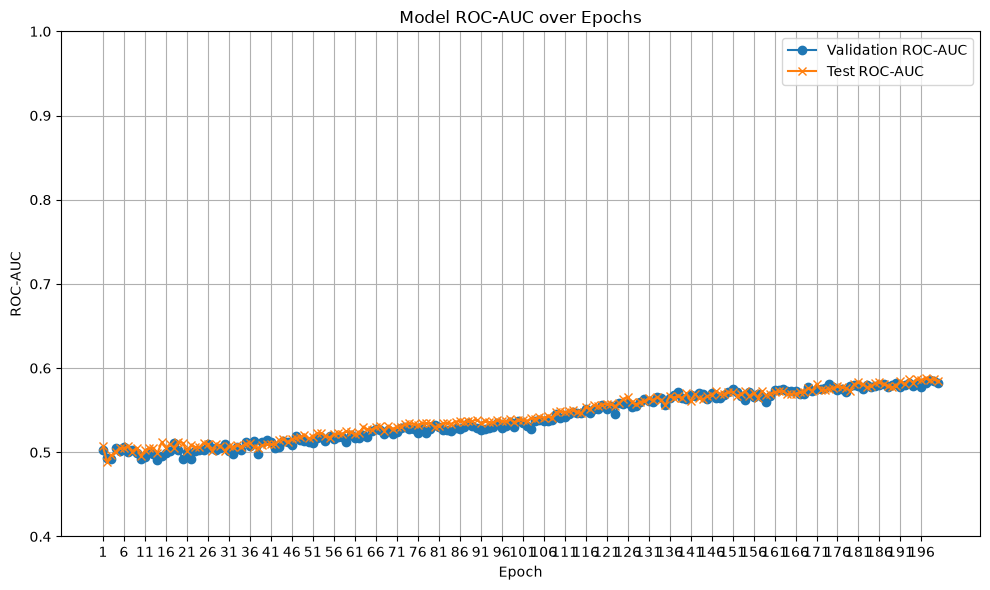

In [21]:
import torch.optim as optim
from torch.nn import BCEWithLogitsLoss
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device) # Move model to device

# Move data to device (only once if not changing)
# For a large graph, you might move mini-batches or only the necessary parts.
# For now, let's assume the full data fits.

train_data = train_data.to(device)
val_data = val_data.to(device)
test_data = test_data.to(device)

# Define Optimizer and Loss Function
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = BCEWithLogitsLoss() # Good for binary classification where output is logits

# --- Placeholder Training Loop ---
def train():
    model.train() # Set model to training mode
    optimizer.zero_grad() # Clear gradients

    # Get node embeddings specific to the training graph structure
    # train_data.edge_attr should now only contain attributes for the positive edges for GNN message passing
    train_node_embeddings = model(train_data.x, train_data.edge_index, train_data.edge_attr)

    # Predict scores for the links in `train_data.edge_label_index` using train_data.edge_label_attr for link features
    train_link_scores = model.predict_link(train_node_embeddings, train_data.edge_label_index) # Pass edge_label_attr

    # The target labels for these links are in `train_data.edge_label`
    loss = loss_fn(train_link_scores, train_data.edge_label.float())

    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate(data_split, split_name):
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        # Use the embeddings from the `train_data`'s graph structure which the model was trained on.
        # train_data.edge_attr should be used here as well for consistency in graph topology used for embedding generation
        eval_node_embeddings = model(train_data.x, train_data.edge_index, train_data.edge_attr)

        scores = model.predict_link(eval_node_embeddings, data_split.edge_label_index) # Pass edge_label_attr
        labels = data_split.edge_label.float()

        current_loss = loss_fn(scores, labels).item()

        # Convert scores to probabilities for AUC calculation
        probs = torch.sigmoid(scores)
        roc_auc = roc_auc_score(labels.cpu().numpy(), probs.cpu().numpy())

    print(f"  {split_name} Loss: {current_loss:.4f}, {split_name} ROC-AUC: {roc_auc:.4f}")
    return current_loss, roc_auc

# Training loop hyperparameters
num_epochs = 200

# Lists to store metrics for plotting
val_auc_history = []
test_auc_history = []

print("\n--- Starting Placeholder Training Loop ---")
for epoch in range(1, num_epochs + 1):
    loss = train()
    print(f"Epoch {epoch:03d}, Train Loss: {loss:.4f}")

    # Evaluate on validation set
    val_loss, val_auc = evaluate(val_data, 'Val')
    val_auc_history.append(val_auc)

    # Evaluate on test set
    test_loss, test_auc = evaluate(test_data, 'Test')
    test_auc_history.append(test_auc)

print("--- Training Complete ---")

# Final evaluation on the test set
print("\n--- Final Test Set Evaluation ---")
test_loss, test_auc = evaluate(test_data, 'Test')
print(f"Final Test Loss: {test_loss:.4f}, Final Test ROC-AUC: {test_auc:.4f}")

# --- Plotting Accuracy (ROC-AUC) over Epochs ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), val_auc_history, label='Validation ROC-AUC', marker='o')
plt.plot(range(1, num_epochs + 1), test_auc_history, label='Test ROC-AUC', marker='x')
plt.title('Model ROC-AUC over Epochs')
plt.xlabel('Epoch')
plt.ylabel('ROC-AUC')
plt.legend()
plt.grid(True)
plt.xticks(range(1, num_epochs + 1, 5)) # Show ticks every 5 epochs
plt.ylim(0.4, 1.0) # Set a reasonable y-limit for AUC
plt.tight_layout()
plt.show()

## Visualizing Node Embeddings

To understand the learned node representations, we will reduce the dimensionality of the node embeddings (produced by the GATv2 model) to 2D using Principal Component Analysis (PCA) and then visualize them. We'll color the nodes based on their original 'type' (zone or crossing) to see if the model has learned to separate these categories in the embedding space.

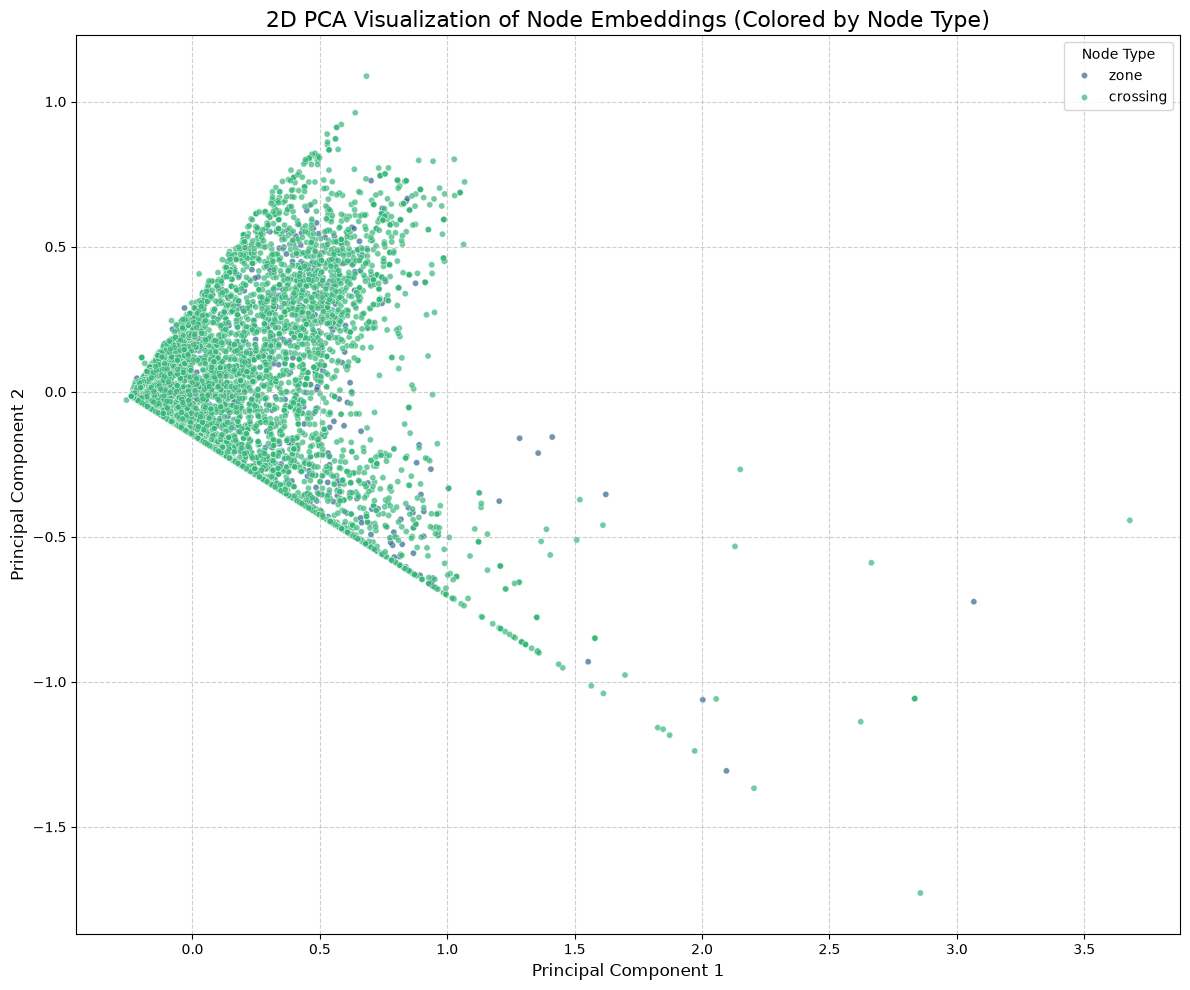

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the model is in evaluation mode
model.eval()

# Get node embeddings from the model using the full graph (data object)
# Move original data.x, data.edge_index, data.edge_attr to the same device as the model
with torch.no_grad():
    full_node_embeddings = model(data.x.to(device), data.edge_index.to(device), data.edge_attr.to(device))

# Move embeddings to CPU for PCA (sklearn works with numpy arrays on CPU)
embeddings_cpu = full_node_embeddings.cpu().numpy()

# Apply PCA to reduce dimensionality to 2 components
pca = PCA(n_components=2)
embeddings_2d_pca = pca.fit_transform(embeddings_cpu)

# Prepare data for plotting
# We need the node types from the original nodes_df
# Ensure nodes_df_sorted (from cell 810493c5) is available and correctly ordered
# (It should be, as it was used to create data.x)
plot_df_pca = pd.DataFrame({
    'component_1': embeddings_2d_pca[:, 0],
    'component_2': embeddings_2d_pca[:, 1],
    'node_type': nodes_df_sorted['type']
})

plt.figure(figsize=(12, 10))
sns.scatterplot(data=plot_df_pca, x='component_1', y='component_2', hue='node_type', palette='viridis', alpha=0.7, s=20)
plt.title('2D PCA Visualization of Node Embeddings (Colored by Node Type)', size=16)
plt.xlabel('Principal Component 1', size=12)
plt.ylabel('Principal Component 2', size=12)
plt.legend(title='Node Type')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Feature Importance: Correlation Analysis

Given the poor performance of the model, it's critical to understand if the input features are actually informative for predicting link presence. We will calculate the Pearson correlation coefficient between each edge feature and the `edge_label` (the binary target variable for link prediction) in the training set. A higher absolute correlation value indicates a stronger linear relationship with the target.

Correlation of each edge feature with 'edge_label':
has_reciprocal             0.003382
link_type_6                0.001590
link_type_9                0.001174
delta_y                    0.001173
capacity_is_placeholder    0.000900
Capacity                   0.000876
Length                     0.000785
link_type_7                0.000620
free_flow_time             0.000545
link_type_2                0.000541
link_type_4                0.000018
link_type_1               -0.001054
capacity_ratio            -0.001362
link_type_3               -0.001655
delta_x                   -0.001798
link_type_8               -0.002083
Toll                      -0.002173
Name: edge_label, dtype: float64


C:\Users\gurke\AppData\Local\Temp\ipykernel_23832\3659160347.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edge_label_correlations.values, y=edge_label_correlations.index, palette='viridis')


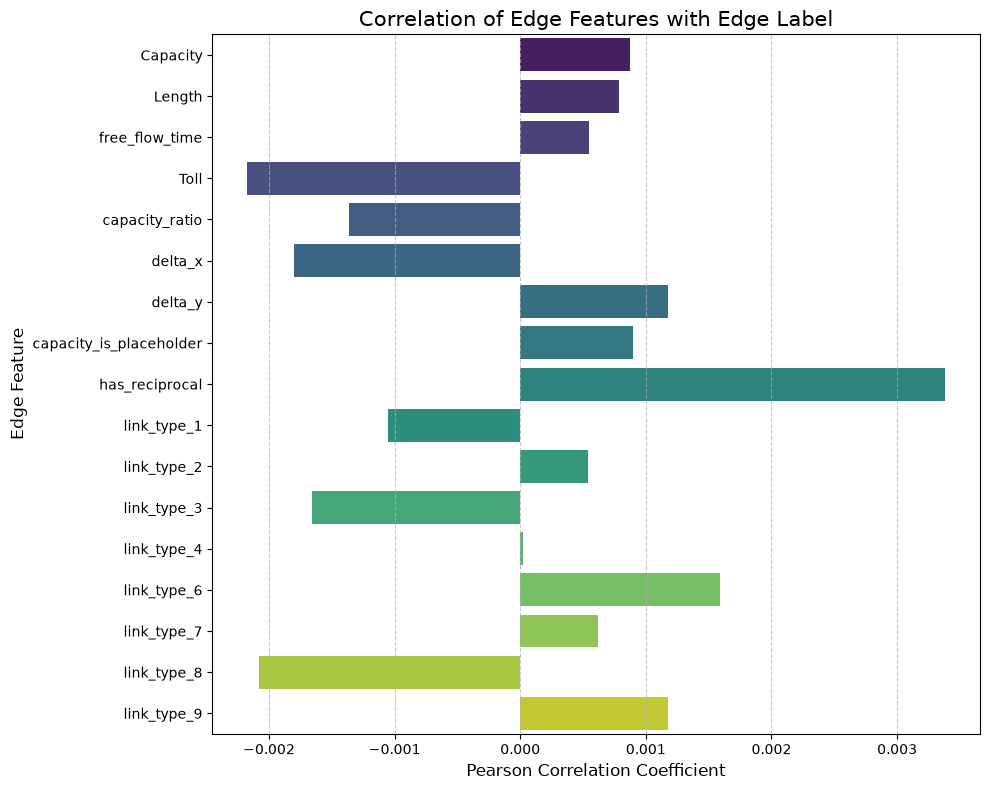

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure data is on CPU for pandas/numpy operations
edge_label_attr_cpu = train_data.edge_label_attr.cpu().numpy()
edge_label_cpu = train_data.edge_label.cpu().numpy()

# Create a DataFrame for correlation analysis
# Use the same column names as used during Data object creation

# Redefine edge_attr_columns to match the actual columns used in edge_attr tensor in 810493c5
numerical_cols = ['Capacity', 'Length', 'free_flow_time', 'Toll', 'capacity_ratio', 'delta_x', 'delta_y'] # Corrected
binary_cols = ['capacity_is_placeholder', 'has_reciprocal'] # Corrected
ohe_cols = [col for col in edges_df.columns if col.startswith('link_type_')]

edge_attr_columns = numerical_cols + binary_cols + ohe_cols

features_df = pd.DataFrame(edge_label_attr_cpu, columns=edge_attr_columns)
features_df['edge_label'] = edge_label_cpu

# Calculate the correlation matrix
correlation_matrix = features_df.corr()

# Extract correlations with the 'edge_label' target
edge_label_correlations = correlation_matrix['edge_label'].drop('edge_label')

print("Correlation of each edge feature with 'edge_label':")
print(edge_label_correlations.sort_values(ascending=False))

# Visualize correlations
plt.figure(figsize=(10, 8))
sns.barplot(x=edge_label_correlations.values, y=edge_label_correlations.index, palette='viridis')
plt.title('Correlation of Edge Features with Edge Label', size=15)
plt.xlabel('Pearson Correlation Coefficient', size=12)
plt.ylabel('Edge Feature', size=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [24]:
philadelphia_path = os.path.join(extract_dir, 'TransportationNetworks-master', 'Philadelphia')

if os.path.exists(philadelphia_path):
    print(f"Contents of '{philadelphia_path}':")
    for root, dirs, files in os.walk(philadelphia_path):
        level = root.replace(philadelphia_path, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f'{subindent}{f}')
else:
    print(f"Error: The path '{philadelphia_path}' does not exist. Please check the extraction.")

Contents of 'TransportationNetworks_master\TransportationNetworks-master\Philadelphia':
Philadelphia/
    Philadelphia_net.tntp
    Philadelphia_node.tntp
    Philadelphia_toll.tntp
    Philadelphia_trips.tntp
    README.md
